# Insurance Cost Prediction: ML Modeling

## Objective
Build and evaluate machine learning models to predict insurance premium prices based on individual health and demographic features.

## Approach
1. Data Preprocessing & Feature Engineering
2. Baseline Model (Linear Regression)
3. Tree-based Models (Decision Tree, Random Forest, Gradient Boosting)
4. Model Comparison and Selection
5. Hyperparameter Tuning
6. Feature Importance and Interpretation

1. **Setup and Imports**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries loaded successfully")

Libraries loaded successfully


**2. Data Loading and Preprocessing**

In [2]:
# Load data
df = pd.read_csv('https://raw.githubusercontent.com/pallabiroyds/insurance-cost-prediction/refs/heads/main/data/insurance.csv')

# Create BMI feature (from EDA notebook)
df['BMI'] = df['Weight'] / (df['Height'] / 100) ** 2

print(f"Dataset: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset: 986 rows, 12 columns


,Age,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,Height,Weight,KnownAllergies,HistoryOfCancerInFamily,NumberOfMajorSurgeries,PremiumPrice,BMI
0,45,0,0,0,0,155,57,0,0,0,25000,23.725286
1,60,1,0,0,0,180,73,0,0,0,29000,22.530864
2,36,1,1,0,0,158,59,0,0,1,23000,23.634033
3,52,1,1,0,1,183,93,0,0,2,28000,27.770313
4,38,0,0,0,1,166,88,0,0,1,23000,31.934969


**3. Train-Test Split**

Splitting data before any further processing to prevent data leakage.
80% training, 20% testing, with a fixed random state for reproducibility.

In [3]:
# Define features and target
X = df.drop(columns=['PremiumPrice'])
y = df['PremiumPrice']

print(f"Features: {X.columns.tolist()}")
print(f"Number of features: {X.shape[1]}")
print()

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set:     {X_test.shape[0]} rows")

Features: ['Age', 'Diabetes', 'BloodPressureProblems', 'AnyTransplants', 'AnyChronicDiseases', 'Height', 'Weight', 'KnownAllergies', 'HistoryOfCancerInFamily', 'NumberOfMajorSurgeries', 'BMI']
Number of features: 11

Training set: 788 rows
Test set:     198 rows


**4. Baseline Model: Linear Regression**

Starting simple to establish a benchmark. All subsequent models must beat this to justify their complexity.

In [4]:
# Scale features for linear regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train baseline
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

# Evaluate
def evaluate_model(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"Model: {name}")
    print(f"  RMSE: {rmse:,.0f}")
    print(f"  MAE:  {mae:,.0f}")
    print(f"  R²:   {r2:.4f}")
    print()
    return {'Model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

results = []
results.append(evaluate_model('Linear Regression', y_test, y_pred_lr))

Model: Linear Regression
  RMSE: 3,494
  MAE:  2,586
  R²:   0.7136



**5. Tree-Based Models**

Testing Decision Tree, Random Forest, and Gradient Boosting. These can capture non-linear patterns and interactions between features that Linear Regression misses.

In [5]:
# Decision Tree
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
results.append(evaluate_model('Decision Tree', y_test, y_pred_dt))

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
results.append(evaluate_model('Random Forest', y_test, y_pred_rf))

# Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
results.append(evaluate_model('Gradient Boosting', y_test, y_pred_gb))

Model: Decision Tree
  RMSE: 4,008
  MAE:  1,288
  R²:   0.6233

Model: Random Forest
  RMSE: 2,135
  MAE:  1,010
  R²:   0.8931

Model: Gradient Boosting
  RMSE: 2,383
  MAE:  1,522
  R²:   0.8669



**Model Comparison:**
- Random Forest is the best performer (R² = 0.893, MAE = 1,010)
- Both ensemble models (RF, GB) significantly outperform Linear Regression, confirming non-linear patterns
- Decision Tree shows signs of overfitting: low MAE but worst RMSE and R², indicating some extreme mispredictions
- Random Forest reduces overfitting by averaging 100 trees
- The baseline Linear Regression (R² = 0.714) was respectable but leaves ~29% of variance unexplained

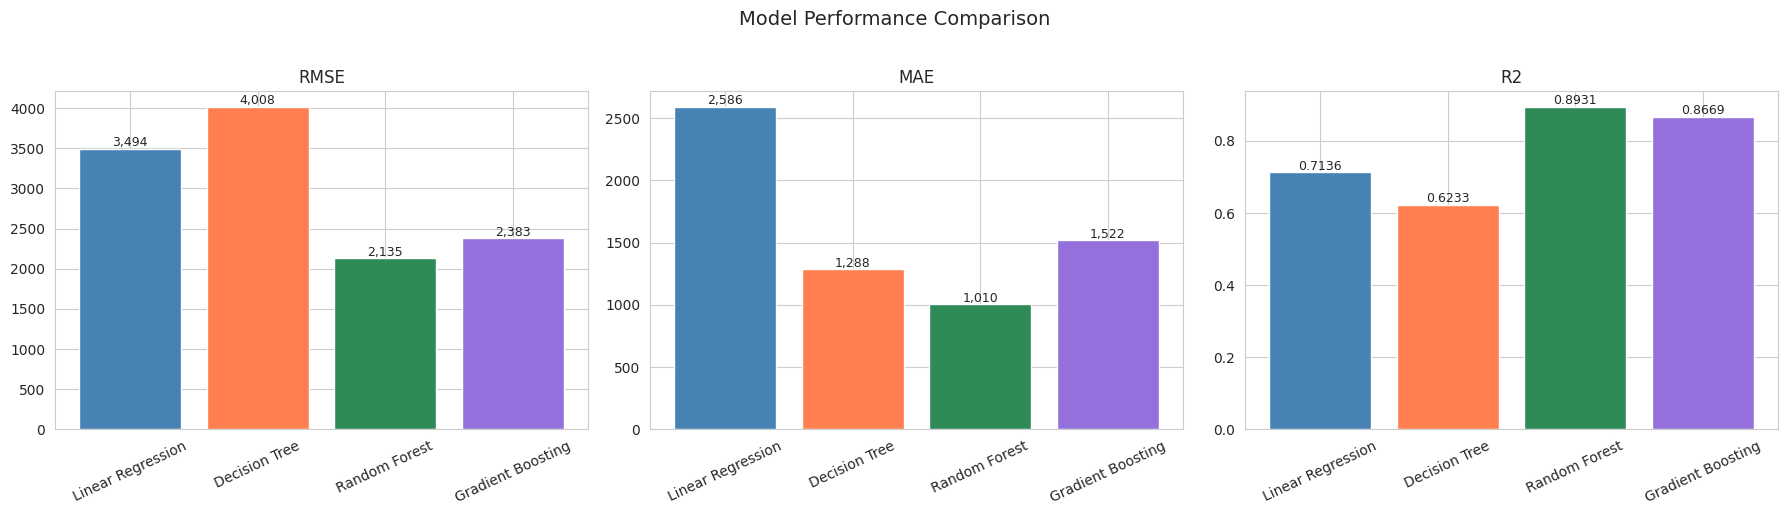

In [6]:
results_df = pd.DataFrame(results)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['steelblue', 'coral', 'seagreen', 'mediumpurple']

for i, metric in enumerate(['RMSE', 'MAE', 'R2']):
    bars = axes[i].bar(results_df['Model'], results_df[metric], color=colors, edgecolor='white')
    axes[i].set_title(metric)
    axes[i].tick_params(axis='x', rotation=25)

    for bar, val in zip(bars, results_df[metric]):
        label = f'{val:,.0f}' if metric != 'R2' else f'{val:.4f}'
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + bar.get_height()*0.01,
                     label, ha='center', fontsize=9)

plt.suptitle('Model Performance Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**6. Cross-Validation**

A single train-test split can be misleading. Cross-validation tests the model on 5 different splits to check if performance is consistent.

In [7]:
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

print("5-FOLD CROSS-VALIDATION (R² Score)")
print("=" * 65)
print(f"{'Model':<22} {'Mean R²':>8} {'Std':>8} {'Min':>8} {'Max':>8}")
print("-" * 65)

cv_results = {}

for name, model in models.items():
    # Use unscaled X for tree models, scaled for linear
    if name == 'Linear Regression':
        X_cv = scaler.fit_transform(X)
    else:
        X_cv = X

    scores = cross_val_score(model, X_cv, y, cv=5, scoring='r2')
    cv_results[name] = scores
    print(f"{name:<22} {scores.mean():>8.4f} {scores.std():>8.4f} {scores.min():>8.4f} {scores.max():>8.4f}")

5-FOLD CROSS-VALIDATION (R² Score)
Model                   Mean R²      Std      Min      Max
-----------------------------------------------------------------
Linear Regression        0.6316   0.0846   0.4850   0.7480
Decision Tree            0.6604   0.0953   0.5032   0.7576
Random Forest            0.7862   0.0678   0.6853   0.8964
Gradient Boosting        0.7546   0.0744   0.6600   0.8828


**Cross-Validation Findings:**
- Random Forest confirmed as best model: highest mean R² (0.786) AND lowest variance (std = 0.068)
- Decision Tree is the least stable (std = 0.095) — performance swings wildly across folds
- Cross-validation R² (0.786) is lower than single split R² (0.893) — CV gives a more realistic estimate
- Random Forest selected for hyperparameter tuning

**7. Hyperparameter Tuning: Random Forest**

Using RandomizedSearchCV to find optimal parameters efficiently.

In [8]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

rf_tuned = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

rf_tuned.fit(X_train, y_train)

print("Best Parameters:")
for param, value in rf_tuned.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest CV R²: {rf_tuned.best_score_:.4f}")

# Evaluate on test set
y_pred_tuned = rf_tuned.predict(X_test)
results.append(evaluate_model('Random Forest (Tuned)', y_test, y_pred_tuned))

Best Parameters:
  n_estimators: 200
  min_samples_split: 10
  min_samples_leaf: 2
  max_features: None
  max_depth: None

Best CV R²: 0.7648
Model: Random Forest (Tuned)
  RMSE: 2,014
  MAE:  1,007
  R²:   0.9049



**Tuning Results:**
- Modest improvement: R² from 0.893 → 0.905, RMSE from 2,135 → 2,014
- Key parameter changes: 200 trees (up from 100), min_samples_split=10 and min_samples_leaf=2 (adds regularization to reduce overfitting)
- The biggest performance gain came from model selection (LR → RF), not hyperparameter tuning
- Tuned Random Forest is our final model

**8. Feature Importance**

Which features does the model rely on most for predictions?

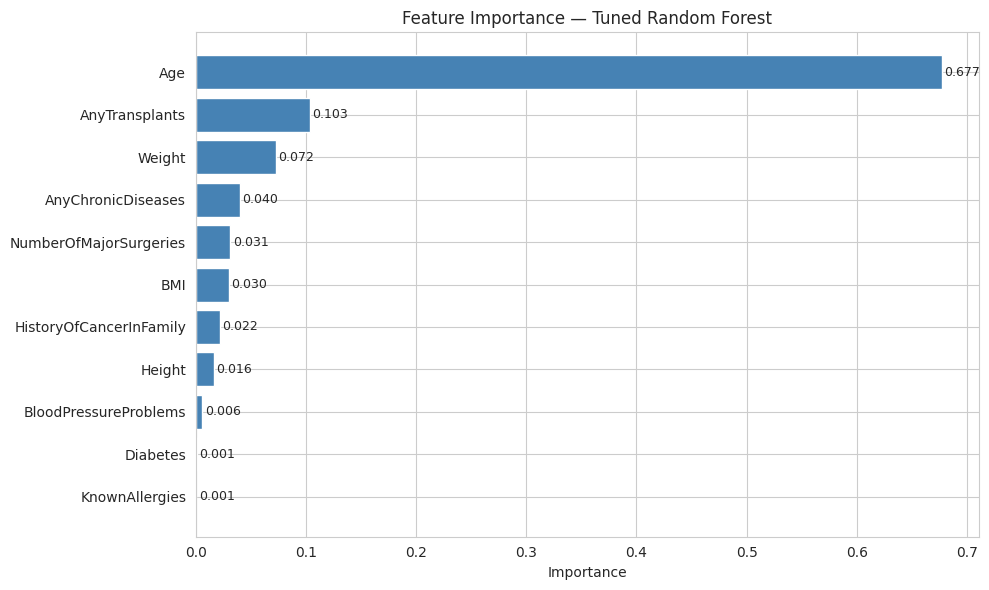

In [9]:
# Get feature importance from the best model
best_rf = rf_tuned.best_estimator_
importances = best_rf.feature_importances_
feature_names = X.columns

# Sort by importance
feat_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp = feat_imp.sort_values('Importance', ascending=True)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feat_imp['Feature'], feat_imp['Importance'], color='steelblue', edgecolor='white')
plt.title('Feature Importance — Tuned Random Forest')
plt.xlabel('Importance')

for i, (imp, name) in enumerate(zip(feat_imp['Importance'], feat_imp['Feature'])):
    plt.text(imp + 0.002, i, f'{imp:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

**Feature Importance Findings:**
- Age dominates (0.677) — accounts for ~68% of the model's predictive power
- AnyTransplants (0.103) is the most important health condition, consistent with EDA
- Weight (0.072) matters more than BMI (0.030) — confirms our EDA finding that the engineered feature didn't improve on the raw one
- Diabetes (0.001) and KnownAllergies (0.001) are essentially ignored by the model
- BloodPressureProblems (0.006) contributes almost nothing despite being statistically significant in hypothesis testing — Age likely absorbs its effect due to multicollinearity

**9. Residual Analysis**

Checking prediction quality — where does the model succeed and where does it fail?

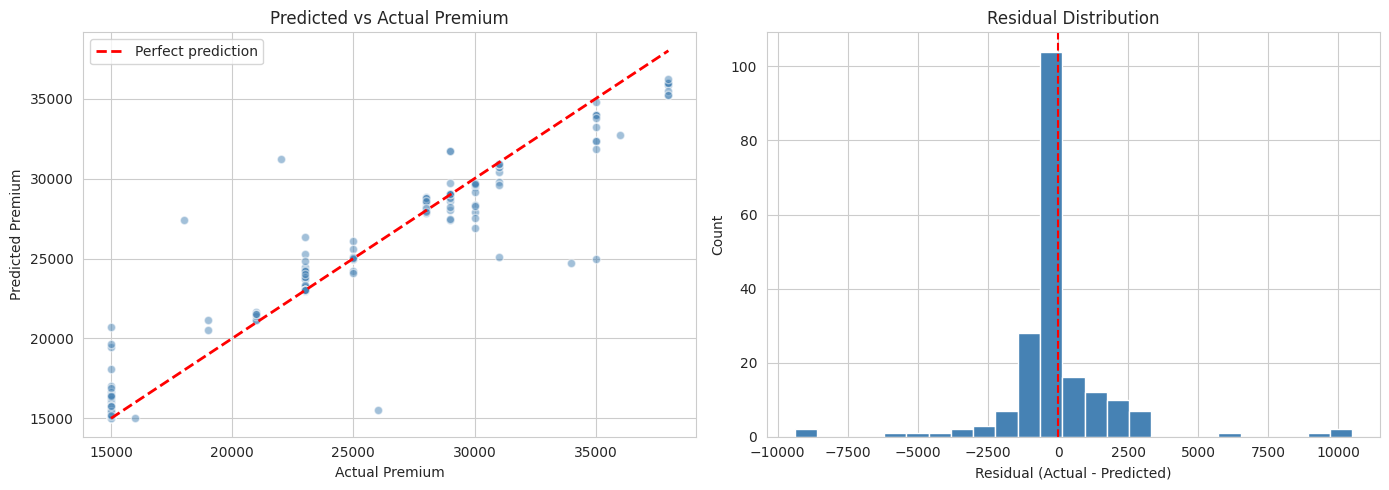

Mean residual: 2
Std residual:  2,019


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs Actual
axes[0].scatter(y_test, y_pred_tuned, alpha=0.5, color='steelblue', edgecolors='white')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_title('Predicted vs Actual Premium')
axes[0].set_xlabel('Actual Premium')
axes[0].set_ylabel('Predicted Premium')
axes[0].legend()

# Residual distribution
residuals = y_test - y_pred_tuned
axes[1].hist(residuals, bins=25, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f"Mean residual: {residuals.mean():,.0f}")
print(f"Std residual:  {residuals.std():,.0f}")

**Residual Analysis:**
- Predicted vs Actual shows strong alignment along the ideal line, especially at premium extremes
- Model struggles most in the 20K-30K mid-range where premium tiers overlap
- Residuals centered around zero — no systematic bias in predictions
- A few outlier predictions off by 7,500-10,000 — likely individuals whose risk profile doesn't follow the typical pattern
- Overall: model performs well with R² = 0.905 and MAE = 1,007

**10. Save Model for Deployment**

Saving the trained model and scaler for use in the Flask API and Streamlit app.

In [12]:
import joblib

# Save the best model
joblib.dump(rf_tuned.best_estimator_, 'best_model.pkl')

# Save the scaler (needed for any linear model comparison, but not for RF)
joblib.dump(scaler, 'scaler.pkl')

# Save feature names for API validation
feature_names = X.columns.tolist()
joblib.dump(feature_names, 'feature_names.pkl')

print("Saved:")
print("  best_model.pkl — Tuned Random Forest")
print("  scaler.pkl — StandardScaler")
print("  feature_names.pkl — Feature list for input validation")
print()
print(f"Features expected by model: {feature_names}")

Saved:
  best_model.pkl — Tuned Random Forest
  scaler.pkl — StandardScaler
  feature_names.pkl — Feature list for input validation

Features expected by model: ['Age', 'Diabetes', 'BloodPressureProblems', 'AnyTransplants', 'AnyChronicDiseases', 'Height', 'Weight', 'KnownAllergies', 'HistoryOfCancerInFamily', 'NumberOfMajorSurgeries', 'BMI']
